In [69]:
from libraries import *
from parameters import *
from sklearn.preprocessing import LabelEncoder

In [2]:
gpu_number=1
str(gpu_number)

'1'

In [70]:
#%run "/home/beraslan/jovian-work/analysisSingle/Notebooks/CombinatorialPerturbations/CVAEModel.ipynb"
%run "/home/beraslan/jovian-work/analysisSingle/Notebooks/CombinatorialPerturbations/CVAEModel_linearGuideEmbedding.ipynb"
%run "/home/beraslan/jovian-work/analysisSingle/Notebooks/CombinatorialPerturbations/SetupFunctions.ipynb"

In [71]:
os.getcwd()
os.chdir(projectDir)

In [72]:
args = setup_args()

In [73]:
net = VAE(n_inputs=args.n_inputs, n_latents=args.n_latents, n_cond=args.n_cond, n_cond_in=args.n_cond_in)

In [74]:
net.load_state_dict(torch.load(os.path.join(args.save_dir,"models/best.pth"))['state_dict'])

<All keys matched successfully>

In [75]:
dataset = E3ScreenDataset(args.trainfile)
dataloader = DataLoader(dataset, batch_size=args.batch_size, drop_last=False, shuffle=False, num_workers=args.num_workers)


In [103]:
def extract_model_embeddings(testloader, model, single_batch=False):
    '''Method for evaluating model based on given criterion'''
    
    model.eval()

    guides = []
    embeddings = []
    conditionEmbeddings = []

    for idx, sample in tqdm(enumerate(testloader)):
        with torch.no_grad():            
            input = sample['y'].cuda() if next(model.parameters()).is_cuda else sample['y']
            condition = sample['X'].cuda() if next(model.parameters()).is_cuda else sample['X']
            embed = model.inference(input, condition)
            conditionEmbed = model.get_embedding(condition)
            
            guides.append(condition.data.cpu().numpy())
            embeddings.append(embed.data.cpu().numpy())
            conditionEmbeddings.append(conditionEmbed.data.cpu.numpy())


        if single_batch and idx == 10:
            break

    guides = np.concatenate(guides, axis=0)
    embeddings = np.concatenate(embeddings, axis=0)    
    conditionEmbeddings = np.concatenate(conditionEmbeddings, axis=0)    
            
    return guides, embeddings, conditionEmbeddings


In [104]:
guides, embeddings, conditionEmbeddings = extract_model_embeddings(testloader=dataloader, model=net, single_batch=args.debug_mode)


0it [00:00, ?it/s]


AttributeError: 'builtin_function_or_method' object has no attribute 'numpy'

In [102]:
guideEmbed = net.

TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [78]:
guides.shape

(101781, 6)

In [79]:
embeddings.shape

(101781, 128)

In [80]:
adata = sc.read('./Notebooks/CombinatorialPerturbations/dataset/adataTrainSingles.h5ad')

In [81]:
adata.shape

(101781, 1041)

In [82]:
adata.obs

,barcode_rank,channel,empty_drops_FDR,log10_n_genes,log10_n_umis,mt_frac,n_counts,n_genes,n_umis,neg_log10_empty_drops_FDR,...,SubCellType_1,SubCellType_2,SubCellType_3,K_0,K_1,K_2,K_3,K_4,K_5,K_CONTROL
AAACGAAAGCAGTCTT-1-E3-1-0-0,6446.0,1,0.0,3.285107,3.714833,0.059391,5186.0,1656,5186.0,4.0,...,0,0,0,0,1,0,0,0,0,0
AAACGAATCTCAACCC-1-E3-1-0-0,4937.0,1,0.0,3.305996,3.756103,0.063300,5703.0,1721,5703.0,4.0,...,0,0,0,0,0,0,1,0,0,0
AAACGCTCAAAGACGC-1-E3-1-0-0,5744.0,1,0.0,3.260310,3.733518,0.065386,5414.0,1567,5414.0,4.0,...,0,0,0,1,0,0,0,0,0,0
AAACGCTCAGTGTACT-1-E3-1-0-0,10821.5,1,0.0,3.251151,3.627366,0.108019,4240.0,1518,4240.0,4.0,...,0,0,0,0,0,1,0,0,0,0
AAAGAACAGCGAGTCA-1-E3-1-0-0,13541.0,1,0.0,3.180699,3.580811,0.051720,3809.0,1300,3809.0,4.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACCAACACATCAACCA-1-E4-1-0-1,9965.0,1,0.0,3.405858,3.889638,0.052733,7756.0,2178,7756.0,4.0,...,0,0,0,0,0,0,0,0,0,1
ACCACAAAGCAGGCAT-1-E4-1-0-1,3186.5,1,0.0,3.489396,4.049567,0.060755,11209.0,2558,11209.0,4.0,...,1,0,0,0,0,0,0,0,0,1
ACCATTTAGCCATGCC-1-E4-1-0-1,5170.0,1,0.0,3.490520,3.989361,0.057901,9758.0,2565,9758.0,4.0,...,0,0,1,0,0,0,0,0,0,1
ACCATTTCAAATGGCG-1-E4-1-0-1,23137.0,1,0.0,3.025306,3.477266,0.051316,3001.0,906,3001.0,4.0,...,0,1,0,0,0,0,0,0,0,1


In [83]:
zs = ["K_0", "K_1","K_2", "K_3", "K_4", "K_5", "K_CONTROL"]

In [84]:
fBarMat_grouped = adata.obs[zs].T

In [85]:
fBarMat_groupedDeneme = fBarMat_grouped.apply(lambda x: ''.join(x.dropna().astype(str)))

In [86]:
fBarMat_groupedDeneme

AAACGAAAGCAGTCTT-1-E3-1-0-0    0100000
AAACGAATCTCAACCC-1-E3-1-0-0    0001000
AAACGCTCAAAGACGC-1-E3-1-0-0    1000000
AAACGCTCAGTGTACT-1-E3-1-0-0    0010000
AAAGAACAGCGAGTCA-1-E3-1-0-0    0100000
                                ...   
ACCAACACATCAACCA-1-E4-1-0-1    0000001
ACCACAAAGCAGGCAT-1-E4-1-0-1    0000001
ACCATTTAGCCATGCC-1-E4-1-0-1    0000001
ACCATTTCAAATGGCG-1-E4-1-0-1    0000001
ACCCAAAAGTTGCCTA-1-E4-1-0-1    0000001
Length: 101781, dtype: object

In [87]:
label_encoder = LabelEncoder()

In [88]:
fBarMat_encodedDF = pd.Series(label_encoder.fit_transform(fBarMat_groupedDeneme))
fBarMat_encodedDF.index = fBarMat_groupedDeneme.index

In [89]:
fBarMat_grouped.sum(axis=1)

K_0          23239
K_1          17826
K_2          16841
K_3          17390
K_4           4667
K_5           1818
K_CONTROL    20000
dtype: int64

In [90]:
fBarMat_encodedDF.value_counts()

6    23239
0    20000
5    17826
3    17390
4    16841
2     4667
1     1818
dtype: int64

In [91]:
adata.obs["perCat"] = fBarMat_encodedDF

In [92]:
fBarMat_encodedDF[fBarMat_encodedDF==6] = "K0"
fBarMat_encodedDF[fBarMat_encodedDF==5] = "K1"
fBarMat_encodedDF[fBarMat_encodedDF==4] = "K2"
fBarMat_encodedDF[fBarMat_encodedDF==3] = "K3"
fBarMat_encodedDF[fBarMat_encodedDF==2] = "K4"
fBarMat_encodedDF[fBarMat_encodedDF==1] = "K5"
fBarMat_encodedDF[fBarMat_encodedDF==0] = "CONTROL"

In [93]:
adata.obs["perCatGroups"] = fBarMat_encodedDF

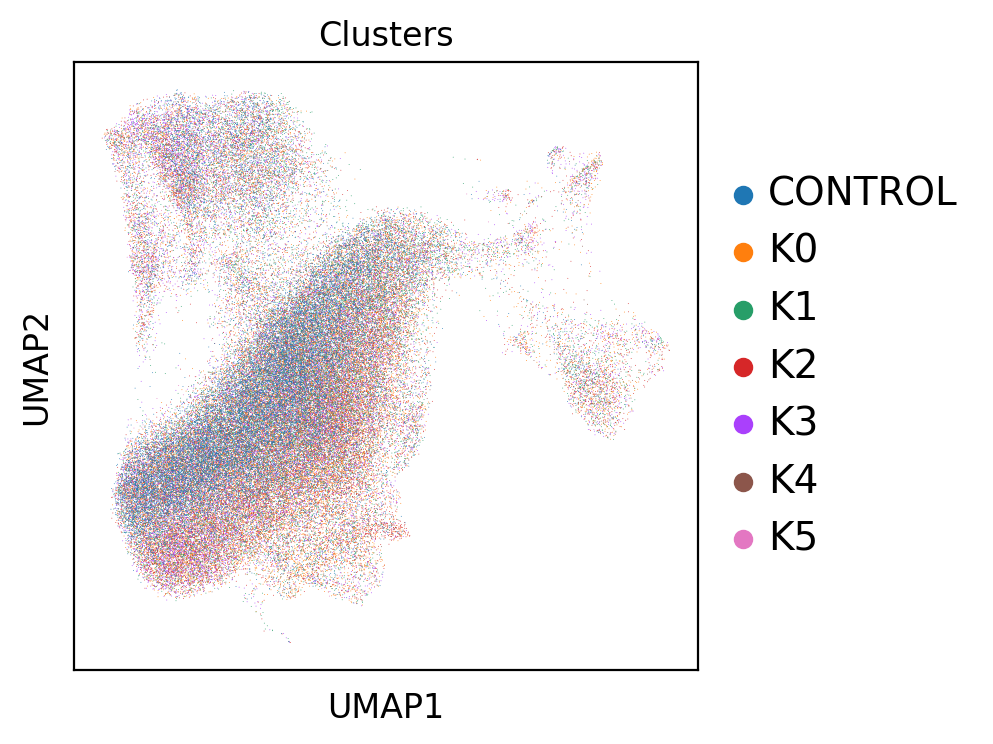

In [94]:
f, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata, color='perCatGroups', 
           legend_fontoutline=3, legend_fontsize=14, 
           legend_fontweight='normal', title='Clusters', ax=ax, show=False, size=0.4);

In [95]:
embeddings[:,0:2].shape

(101781, 2)

In [96]:
embAnnDat = sc.AnnData(X=embeddings) 


In [97]:
embAnnDat.obs.index = adata.obs.index

In [98]:
embAnnDat.obs["perCatGroups"] = adata.obs["perCatGroups"]

In [99]:
sc.pp.neighbors(embAnnDat, n_neighbors=15, use_rep='X')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:12)


In [100]:
sc.tl.umap(embAnnDat)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:16)


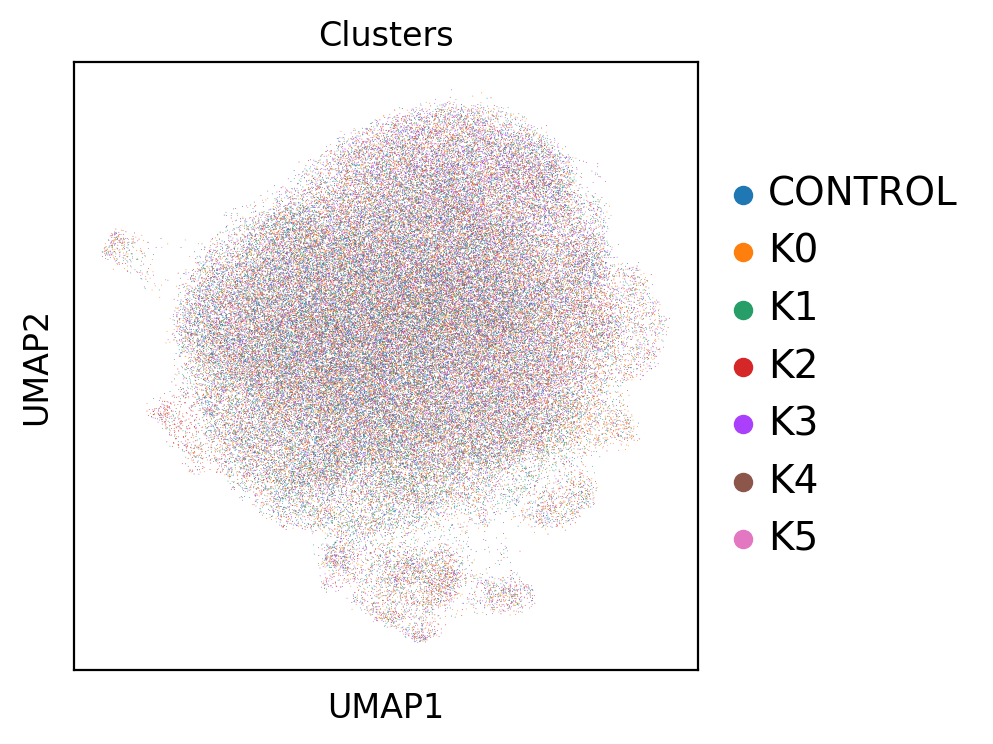

In [101]:
f, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(embAnnDat, color='perCatGroups', 
           legend_fontoutline=3, legend_fontsize=14, 
           legend_fontweight='normal', title='Clusters', ax=ax, show=False, size=0.4);

In [55]:
embAnnDat.obs["perCatGroups"]

AAACGAAAGCAGTCTT-1-E3-1-0-0         K1
AAACGAATCTCAACCC-1-E3-1-0-0         K3
AAACGCTCAAAGACGC-1-E3-1-0-0         K0
AAACGCTCAGTGTACT-1-E3-1-0-0         K2
AAAGAACAGCGAGTCA-1-E3-1-0-0         K1
                                ...   
ACCAACACATCAACCA-1-E4-1-0-1    CONTROL
ACCACAAAGCAGGCAT-1-E4-1-0-1    CONTROL
ACCATTTAGCCATGCC-1-E4-1-0-1    CONTROL
ACCATTTCAAATGGCG-1-E4-1-0-1    CONTROL
ACCCAAAAGTTGCCTA-1-E4-1-0-1    CONTROL
Name: perCatGroups, Length: 101781, dtype: category
Categories (7, object): ['CONTROL', 'K0', 'K1', 'K2', 'K3', 'K4', 'K5']